# Axle Counter Parameter Sweep & Concept Explanations
> **Scope note — this is a LEGACY, self-contained sweep.**
> This notebook deliberately does *not* use the FEMM-verified anchor in `config.py`.
> It builds its own coupling model from an assumed flux-loss efficiency
> ($\eta pprox 10^{-4}$) and its own hard-coded geometry — `N_s = 60`,
> `A_p = 100` cm² — which do **not** match `config.BASELINE_TURNS = 100` or
> `config.COIL_RADIUS_M = 0.035` (`A_REF` ≈ 38.5 cm²). Its coupling therefore
> disagrees with `physics_calculation.ipynb` (which reports $k pprox 0.15$) by
> orders of magnitude.
>
> These constants are kept **unchanged on purpose**: `reports/axle_counter_sweep_data.csv`
> produced here feeds figures 05–09 and is validated by `sanity_check.py` as a legacy
> artifact. Treat the numbers below as a worst-case flux-loss study, **not** as a
> prediction of the built coil. For FEMM-anchored physics use
> `physics_calculation.ipynb` and `config.M0_UH`.

This notebook explores the parameter space for an axle counter's primary coil. We perform extensive sweeps across flux loss, primary turns, frequency, and wire gauge.

## Concept Explanations (The "Complicated Terms")

### 1. Magnetic Flux Loss & Coupling Efficiency
* **Magnetic Flux ($\Phi$):** Think of this as the "amount of magnetic field" flowing through a loop. The primary coil generates flux.
* **Flux Loss:** In an ideal transformer, 100% of the flux generated by the primary coil goes through the secondary coil. In our open-air axle counter, most of the magnetic field leaks into the surrounding space. 
* **99.99% Flux Loss:** This means only $0.01\%$ (or $10^{-4}$) of the magnetic flux generated by the primary coil actually manages to pass through the secondary coil. The remaining 99.99% is "lost" to the environment. We call this a coupling efficiency ($\eta$) of $10^{-4}$.

### 2. Skin Effect
* **What is it?** When alternating current (AC) flows through a wire, the changing magnetic field pushes the electrons toward the outer surface ("skin") of the wire. 
* **Why does it matter?** Because the current is squished into a thinner layer near the surface, the effective cross-sectional area of the wire is reduced. A smaller area means **higher resistance**.
* **Skin Depth ($\delta$):** This is the depth from the surface where most of the current flows. As frequency increases, the skin depth decreases (the layer gets thinner), and the AC resistance ($R_{AC}$) increases compared to standard DC resistance ($R_{DC}$).

### 3. Inductive Reactance ($X_L$) & Impedance ($Z$)
* **Inductance ($L$):** A coil's resistance to *changes* in current.
* **Inductive Reactance ($X_L = 2\pi f L$):** In an AC circuit, an inductor opposes the flow of current. The higher the frequency ($f$) or inductance ($L$), the harder it is to push AC current through it. It acts like "AC resistance" but is measured in Ohms ($\Omega$).
* **Impedance ($Z$):** The total opposition to current flow, combining both standard wire resistance ($R_{AC}$) and inductive reactance ($X_L$). $Z = \sqrt{R_{AC}^2 + X_L^2}$.

### 4. Resonant Matching (Tuning)
* **The Problem:** Because our coil has high inductance and we are operating at high frequencies (10-20 kHz), the Inductive Reactance ($X_L$) is massive. To push the required current through this massive reactance, we need extremely high voltages (thousands of volts).
* **The Solution:** We add a capacitor in series with the coil. Capacitors have "Capacitive Reactance" ($X_C$) which is exactly opposite in phase to Inductive Reactance. If we choose a capacitor such that $X_C = X_L$, they completely cancel each other out! 
* **The Result:** The only opposition left in the *driving loop* is the wire resistance ($R_{AC}$), so the **supply** voltage drops sharply — `Resonant_Voltage_Peak_V` spans 0.13 V to 2.50 kV across this sweep, versus up to 50.1 kV uncompensated.
* **The catch (do not skip this):** resonance does **not** make the kilovolts go away, it *relocates* them onto the capacitor. At resonance $V_C = I\cdot X_C = I\cdot X_L$, which is exactly the reactive voltage we just cancelled. The `Capacitor_Voltage_Peak_V` column of the CSV written below ranges **50 V to 50 kV** — the high-voltage problem becomes a *capacitor voltage-rating* problem. This is why `optimize_air_core.py` sizes the design against standard 250/630/1000/2000 V film-cap classes rather than maximising signal blindly.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from mpl_toolkits.mplot3d import Axes3D

# Output goes to the canonical reports folder (the old hard-coded .gemini
# path is dead; that migration script now lives in old_files/).
# Load the shared configuration. The notebook lives in a subfolder, so walk
# UP from the CWD until config.py is found -- this works whether Jupyter was
# launched in analysis_and_reporting/ or at the project root. (The old
# `sys.path.append(os.path.abspath(""))` pointed at the notebook's own folder
# and raised ModuleNotFoundError after the project was reorganised.)
_d = os.path.abspath("")
while _d != os.path.dirname(_d) and not os.path.exists(os.path.join(_d, "config.py")):
    _d = os.path.dirname(_d)
if _d not in sys.path:
    sys.path.insert(0, _d)
import config
artifacts_dir = config.OUTPUT_DIR
os.makedirs(artifacts_dir, exist_ok=True)

# Constants
mu0 = 4 * np.pi * 1e-7
rho_copper = 1.68e-8
V_s_peak = 1.5 # 3 Vpp target
N_s = 60
A_s = 600 * 1e-4
r_s = np.sqrt(A_s / np.pi)
A_p = 100 * 1e-4
r_p = np.sqrt(A_p / np.pi)

# Standard AWG Diameters (in mm)
awg_dict = {
    20: 0.8128,
    22: 0.64516,
    24: 0.51054,
    26: 0.40386,
    28: 0.32004,
    30: 0.254,
    32: 0.2032,
    34: 0.16002
}

# Sweep Parameters
flux_losses_pct = np.append(np.arange(95.0, 100.0, 0.1), 99.99)
N_ps = np.arange(100, 201, 20)
freqs = np.arange(10000, 20500, 500)
gauges = np.arange(20, 36, 2)


In [2]:
def get_ac_resistance(R_dc, a, freq):
    delta = np.sqrt(rho_copper / (np.pi * freq * mu0))
    x = a / delta
    if x < 1.0:
        factor = 1.0 + (x**4) / 48.0
    else:
        factor = x / 2.0 + 0.75 + 3.0 / (32.0 * x)
    return R_dc * factor

def calculate_parameters(freq, N_p, flux_loss_pct, gauge):
    # Wire radius
    a = (awg_dict[gauge] / 2.0) * 1e-3
    
    # Primary Inductance
    L_p = mu0 * (N_p**2) * r_p * (np.log((8 * r_p) / a) - 2.0)
    
    # Mutual Inductance (Interpretation A: Flux Ratio)
    eta = 1.0 - (flux_loss_pct / 100.0)
    M = eta * (N_s / N_p) * L_p
    
    # Resistance
    l_wire = N_p * 2 * np.pi * r_p
    A_wire = np.pi * (a**2)
    R_dc = rho_copper * l_wire / A_wire
    R_ac = get_ac_resistance(R_dc, a, freq)
    
    # Required Current
    omega = 2 * np.pi * freq
    I_p_peak = V_s_peak / (omega * M)
    
    # Required Voltages
    X_p = omega * L_p
    Z_p = np.sqrt(R_ac**2 + X_p**2)
    
    V_p_peak_uncomp = I_p_peak * Z_p
    V_p_peak_res = I_p_peak * R_ac
    
    # Capacitor Properties
    C_p = 1.0 / (omega**2 * L_p)
    V_C_peak = I_p_peak * X_p # Voltage across capacitor at resonance
    
    return I_p_peak, V_p_peak_uncomp, V_p_peak_res, C_p, V_C_peak


## Parameter Sweep Visualizations
Since visualizing 4 parameters (Freq, N_p, Flux Loss, Gauge) simultaneously is difficult, we will fix a standard gauge (e.g., AWG 24) and plot the relationships for Current and Voltage across Frequencies, varying N_p and Flux Loss. We will also show how the gauge affects Resonant Voltage.


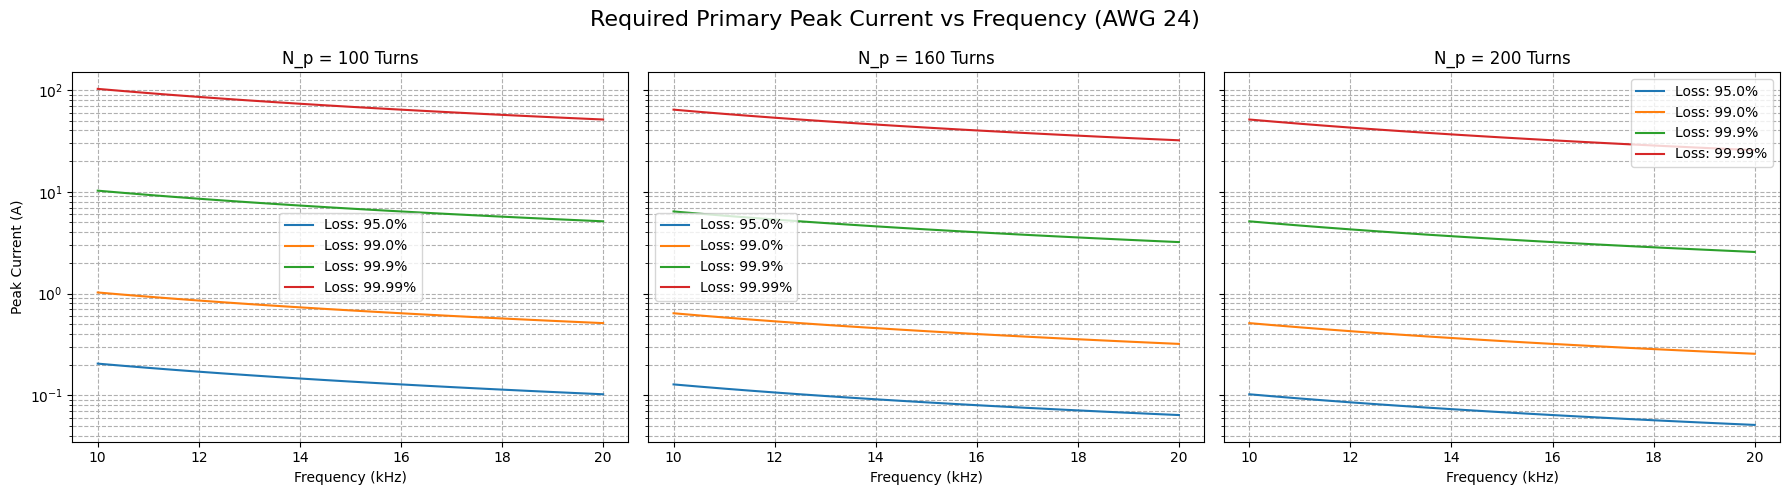

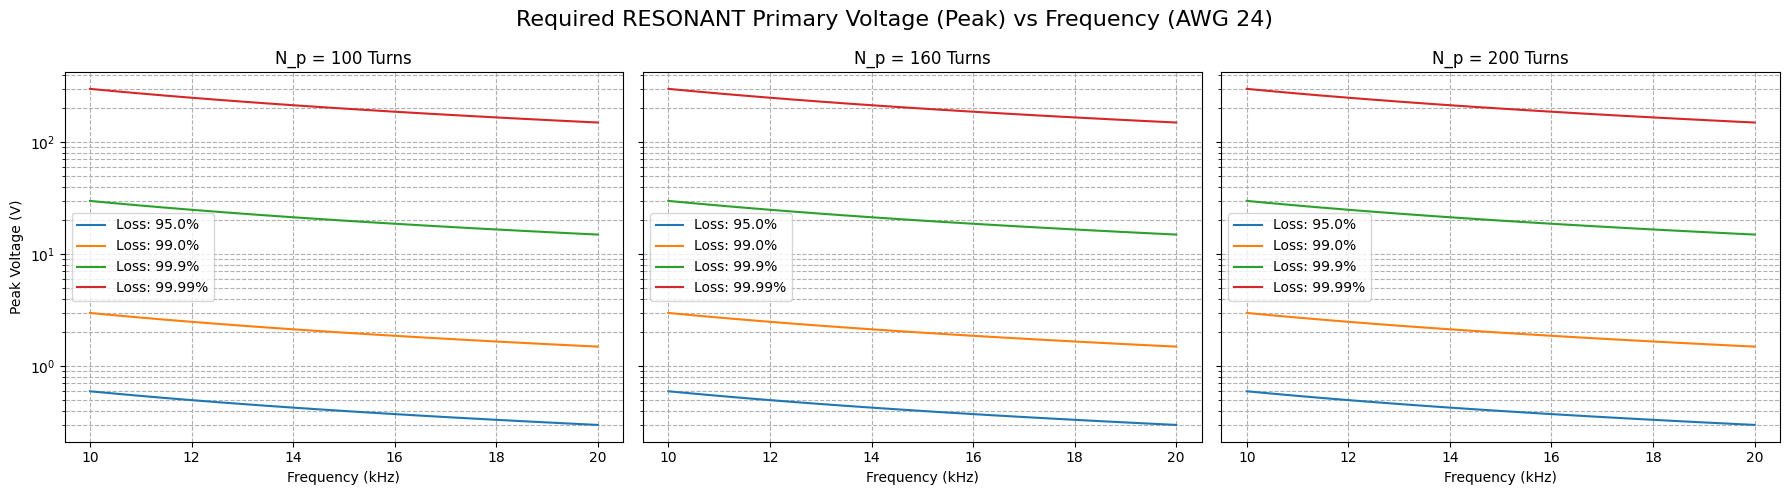

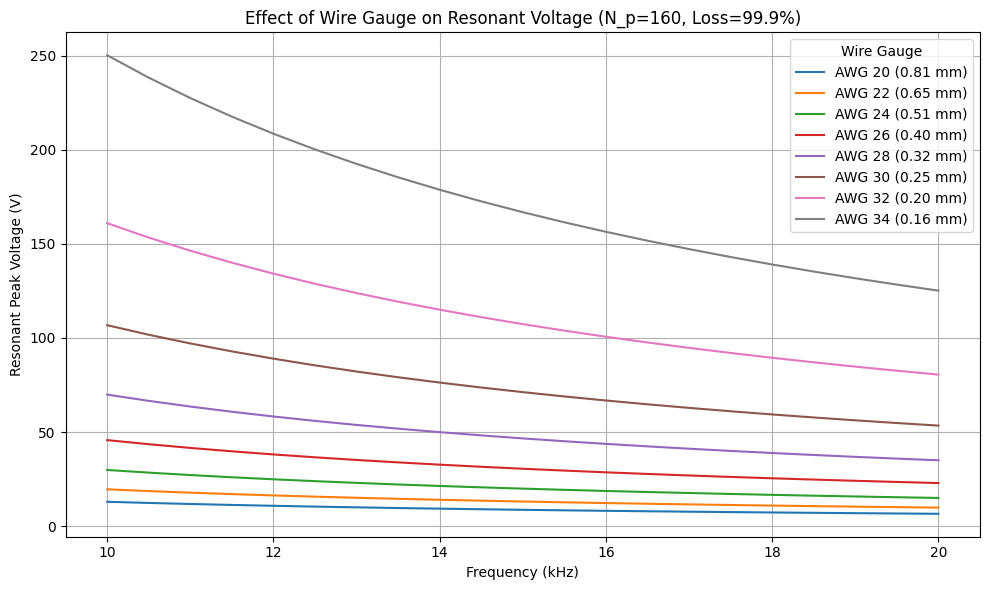

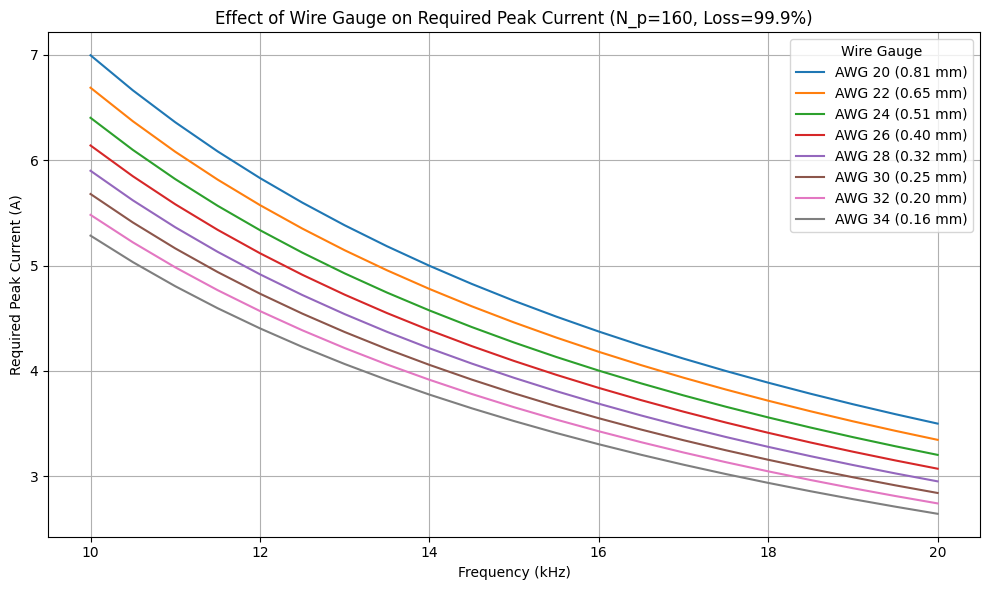

Spreadsheet generated and saved to: C:\Users\rudra\Axle_counter\axlecounter_3dphysics\reports\axle_counter_sweep_data.csv
Sweep generated and plots saved to artifacts directory: C:\Users\rudra\Axle_counter\axlecounter_3dphysics\reports


In [3]:
# 1. Plot: Current vs Frequency (Varying Flux Loss and N_p)
# We select a few representative flux losses for clarity to avoid clutter
selected_fluxes = [95.0, 99.0, 99.9, 99.99]
selected_Nps = [100, 160, 200]
fixed_gauge = 24

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Required Primary Peak Current vs Frequency (AWG 24)', fontsize=16)

for i, N_p in enumerate(selected_Nps):
    ax = axes[i]
    for fl in selected_fluxes:
        currents = [calculate_parameters(f, N_p, fl, fixed_gauge)[0] for f in freqs]
        ax.plot(freqs / 1e3, currents, label=f'Loss: {fl}%')
    ax.set_title(f'N_p = {N_p} Turns')
    ax.set_xlabel('Frequency (kHz)')
    ax.set_ylabel('Peak Current (A)' if i==0 else '')
    ax.set_yscale('log') # Log scale because 99.99% loss requires massive current compared to 95%
    ax.grid(True, which="both", ls="--")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(artifacts_dir, 'sweep_current.png'), dpi=150)
plt.show()

# 2. Plot: Resonant Driving Voltage vs Frequency (Varying Flux Loss and N_p)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Required RESONANT Primary Voltage (Peak) vs Frequency (AWG 24)', fontsize=16)

for i, N_p in enumerate(selected_Nps):
    ax = axes[i]
    for fl in selected_fluxes:
        v_res = [calculate_parameters(f, N_p, fl, fixed_gauge)[2] for f in freqs]
        ax.plot(freqs / 1e3, v_res, label=f'Loss: {fl}%')
    ax.set_title(f'N_p = {N_p} Turns')
    ax.set_xlabel('Frequency (kHz)')
    ax.set_ylabel('Peak Voltage (V)' if i==0 else '')
    ax.set_yscale('log')
    ax.grid(True, which="both", ls="--")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(artifacts_dir, 'sweep_voltage_res.png'), dpi=150)
plt.show()

# 3. Plot: Effect of Wire Gauge on Resonant Voltage (Fixed N_p=160, Loss=99.9%)
fig, ax = plt.subplots(figsize=(10, 6))
N_p_fixed = 160
fl_fixed = 99.9

for g in gauges:
    v_res = [calculate_parameters(f, N_p_fixed, fl_fixed, g)[2] for f in freqs]
    ax.plot(freqs / 1e3, v_res, label=f'AWG {g} ({awg_dict[g]:.2f} mm)')

ax.set_title(f'Effect of Wire Gauge on Resonant Voltage (N_p={N_p_fixed}, Loss={fl_fixed}%)')
ax.set_xlabel('Frequency (kHz)')
ax.set_ylabel('Resonant Peak Voltage (V)')
ax.grid(True)
ax.legend(title="Wire Gauge")

plt.tight_layout()
plt.savefig(os.path.join(artifacts_dir, 'sweep_gauge.png'), dpi=150)
plt.show()

# 4. Plot: Effect of Wire Gauge on Peak Current (Fixed N_p=160, Loss=99.9%)
fig, ax = plt.subplots(figsize=(10, 6))

for g in gauges:
    i_peak = [calculate_parameters(f, N_p_fixed, fl_fixed, g)[0] for f in freqs]
    ax.plot(freqs / 1e3, i_peak, label=f'AWG {g} ({awg_dict[g]:.2f} mm)')

ax.set_title(f'Effect of Wire Gauge on Required Peak Current (N_p={N_p_fixed}, Loss={fl_fixed}%)')
ax.set_xlabel('Frequency (kHz)')
ax.set_ylabel('Required Peak Current (A)')
ax.grid(True)
ax.legend(title="Wire Gauge")

plt.tight_layout()
plt.savefig(os.path.join(artifacts_dir, 'sweep_gauge_current.png'), dpi=150)
plt.show()

# 5. Spreadsheet Generation
import csv
csv_path = os.path.join(artifacts_dir, 'axle_counter_sweep_data.csv')
with open(csv_path, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['Frequency_Hz', 'Primary_Turns_Np', 'Flux_Loss_Pct', 'Wire_Gauge_AWG', 
                     'Peak_Current_A', 'Uncomp_Voltage_Peak_V', 'Resonant_Voltage_Peak_V', 
                     'Capacitor_Value_F', 'Capacitor_Voltage_Peak_V'])
    
    for f in freqs:
        for N in selected_Nps:
            for fl in selected_fluxes:
                for g in [20, 24, 28, 34]:
                    I_p, V_u, V_r, C_p, V_C = calculate_parameters(f, N, fl, g)
                    writer.writerow([f, N, fl, g, I_p, V_u, V_r, C_p, V_C])

print(f"Spreadsheet generated and saved to: {csv_path}")

# 6. Summary Output
print(f"Sweep generated and plots saved to artifacts directory: {artifacts_dir}")
